In [4]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense
from keras.models import Sequential, load_model
import random

import warnings
warnings.filterwarnings('ignore')

seed_value=40

In [5]:
data = pd.read_csv('flight_satisfaction (1).csv', encoding='latin-1')

columns_to_fill = ["Gender", "Customer Type", "Class", "Food and drink", "Seat comfort", "On-board service", "Leg room service", "Checkin service"]

In [6]:
# fill empty data with median
for columns in columns_to_fill:
    if pd.api.types.is_numeric_dtype(data[columns]):
        median_value = data[columns].median()
        data[columns].fillna(median_value, inplace=True)

In [7]:
#Dropping Duplicate Files
data_no_duplicates = data.drop_duplicates(subset=columns_to_fill)

In [8]:
#Dealing with Outliers
def handle_outliers_iqr(column):
    if pd.api.types.is_numeric_dtype(columns):
        Q1 = data[column].quantile(0.25)
        Q3 = data[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outlier_mask = (data[column] < lower_bound) | (data[column] > upper_bound)
        data[column+'_outlier'] = outlier_mask
        #data[column] = data[column].clip(lower=lower_bound, upper=upper_bound)
        data.drop(data[outlier_mask].index, inplace=False)


for column in columns_to_fill:
    handle_outliers_iqr(column)

In [9]:
data[columns_to_fill]

,Gender,Customer Type,Class,Food and drink,Seat comfort,On-board service,Leg room service,Checkin service
0,Male,Loyal Customer,Eco Plus,5,5,4,3,4
1,Male,disloyal Customer,Business,1,1,1,5,1
2,Female,Loyal Customer,Business,5,5,4,3,4
3,Female,Loyal Customer,Business,2,2,2,5,1
4,Male,Loyal Customer,Business,4,5,3,4,3
...,...,...,...,...,...,...,...,...
103900,Male,Loyal Customer,Business,2,5,5,5,5
103901,Male,disloyal Customer,Business,4,5,3,2,5
103902,Female,disloyal Customer,Eco,1,1,4,5,5
103903,Male,Loyal Customer,Business,1,1,1,1,4


In [10]:
# Print the shape of the DataFrame before and after removing duplicates
print("Shape before removing duplicates:", data.shape)
print("Shape after removing duplicates:", data_no_duplicates.shape)

Shape before removing duplicates: (103905, 25)
Shape after removing duplicates: (16681, 25)


In [11]:
# Save the DataFrame without duplicates to a new CSV file
output_csv_path = 'data_filled.csv'

data.to_csv(output_csv_path, index=False)
data_no_duplicates.to_csv(output_csv_path, index=False)

# Print a message to confirm the save operation
print(f"DataFrame with filled missing values saved to {output_csv_path}")
print(f"DataFrame without duplicates saved to {output_csv_path}")
print(f"DataFrame with filled missing values and handled outliers saved to {output_csv_path}")

DataFrame with filled missing values saved to data_filled.csv
DataFrame without duplicates saved to data_filled.csv
DataFrame with filled missing values and handled outliers saved to data_filled.csv


In [12]:
# Columns to Convert the type
column_customer = 'Customer Type'
column_class = 'Class'
column_gender = 'Gender'
column_satisfaction = 'satisfaction'


# Mapping
data[column_customer] = data[column_customer].map({'disloyal Customer' : 0, 'Loyal Customer' : 1})
data[column_class] = data[column_class].map({'Eco' : 0, 'Eco Plus' : 1, 'Business' : 2})
data[column_gender] = data[column_gender].map({'Male' : 0, 'Female' : 1})
data[column_satisfaction] = data[column_satisfaction].map({'neutral or dissatisfied': 0,'satisfied': 1})

In [13]:
# Z-score Normalizing
for column in columns_to_fill:
    if pd.api.types.is_numeric_dtype(data[column]):
        mean_value = data[column].mean()
        std_deviation = data[column].std()
        data[column] = (data[column] - mean_value) / std_deviation

In [14]:
data

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0.0,70172,-1.015016,0.472762,13,Personal Travel,-0.029187,460,3,4,...,5,0.479397,-0.266838,4,0.549793,5,5,25,18.0,0
1,1.0,5047,-1.015016,-2.115210,25,Business travel,1.009393,235,3,2,...,1,-1.849163,1.253383,3,-1.821015,4,1,1,6.0,0
2,2.0,110028,0.985197,0.472762,26,Business travel,1.009393,1142,2,2,...,5,0.479397,-0.266838,4,0.549793,4,5,0,0.0,1
3,3.0,24026,0.985197,0.472762,25,Business travel,1.009393,562,2,5,...,2,-1.072976,1.253383,3,-1.821015,4,2,11,9.0,0
4,4.0,119299,-1.015016,0.472762,61,Business travel,1.009393,214,3,3,...,3,-0.296789,0.493272,4,-0.240477,3,3,0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103900,103900.0,73097,-1.015016,0.472762,49,Business travel,1.009393,2347,4,4,...,5,1.255584,1.253383,5,1.340062,5,4,0,0.0,1
103901,103901.0,68825,-1.015016,-2.115210,30,Business travel,1.009393,1995,1,1,...,4,-0.296789,-1.026948,4,1.340062,5,4,7,14.0,0
103902,103902.0,54173,0.985197,-2.115210,22,Business travel,-1.067767,1000,1,1,...,1,0.479397,1.253383,1,1.340062,4,1,0,0.0,0
103903,103903.0,62567,-1.015016,0.472762,27,Business travel,1.009393,1723,1,3,...,1,-1.849163,-1.787058,4,0.549793,3,1,0,0.0,0


In [15]:
# Save the DataFrame with changes to a new CSV file
data.to_csv(output_csv_path, index=False)

# Print a message to confirm the save operation
print(f"DataFrame with changes saved to {output_csv_path}")

DataFrame with changes saved to data_filled.csv


In [16]:
df = data.sample(2000, random_state=seed_value)
if 'satisfaction' not in columns_to_fill:
    columns_to_fill.append('satisfaction')
df = df[columns_to_fill]

In [17]:
train_data, test_data = df[:2000 * 8 // 10], df[2000 * 8 // 10:]

In [18]:
test_data

,Gender,Customer Type,Class,Food and drink,Seat comfort,On-board service,Leg room service,Checkin service,satisfaction
31866,0.985197,0.472762,-1.067767,-0.152042,-0.333117,0.479397,-0.266838,-1.821015,0
56595,0.985197,0.472762,1.009393,-0.904183,0.424982,-0.296789,-0.266838,-1.821015,0
66412,-1.015016,0.472762,-0.029187,0.600099,0.424982,-0.296789,0.493272,0.549793,1
68221,-1.015016,0.472762,1.009393,-0.904183,0.424982,0.479397,0.493272,1.340062,1
78575,0.985197,-2.115210,-0.029187,-0.152042,-0.333117,-1.849163,0.493272,-1.821015,0
...,...,...,...,...,...,...,...,...,...
25539,-1.015016,0.472762,-1.067767,-0.152042,-1.849313,-0.296789,0.493272,-0.240477,0
57067,-1.015016,0.472762,-0.029187,1.352239,1.183080,1.255584,-1.026948,-0.240477,1
30485,0.985197,-2.115210,1.009393,-0.152042,-0.333117,-0.296789,-0.266838,-0.240477,0
92127,0.985197,0.472762,1.009393,-0.152042,1.183080,0.479397,0.493272,0.549793,1


In [19]:
x_train, y_train = train_data.iloc[:,:-1], train_data.iloc[:,-1]
x_test, y_test = test_data.iloc[:,:-1], test_data.iloc[:,-1]

In [20]:
model = Sequential([
    Dense(units=25, activation='relu', input_shape=(8,)),
    Dense(units=15, activation='relu'),
    Dense(units=10, activation='linear'),
    Dense(units=1, activation='sigmoid'),
])

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 25)                  │             225 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 15)                  │             390 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 786 (3.07 KB)

 Trainable params: 786 (3.07 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
def loss_fn(y_true, y_pred):
    epsilon = 1e-15  # Small constant to avoid log(0) issues
    y_pred = tf.clip_by_value(y_pred, epsilon, 1 - epsilon)  # Clip predicted values to avoid numerical instability
    binary_crossentropy_loss = - (y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred))
    return tf.reduce_mean(binary_crossentropy_loss)

In [23]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history1 = model.fit(x_train, y_train, epochs=100)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5508 - loss: 0.6846
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 869us/step - accuracy: 0.7801 - loss: 0.4930
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - accuracy: 0.8092 - loss: 0.4195
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 836us/step - accuracy: 0.8195 - loss: 0.4073
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 814us/step - accuracy: 0.8113 - loss: 0.4121
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 835us/step - accuracy: 0.8302 - loss: 0.3884
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step - accuracy: 0.8177 - loss: 0.4106
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 887us/step - accuracy: 0.8166 - loss: 0.3998
Epoch 9/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 864us/step - accuracy: 0.8455 - loss: 0.3674
Epoch 10/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 951us/step - accuracy: 0.8236 - loss: 0.3862
Epoch 11/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 878us/step - accuracy: 0.8222 - loss: 0.3800
Epoch 12/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [24]:
pred = model.predict(tf.constant(df.iloc[1][:-1].values.reshape(-1, 8)))
threshold = 0.5
bipred = (pred > threshold).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


In [25]:
pred = model.predict(x_test)
bipred = (pred > threshold).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


In [26]:
import matplotlib.pyplot as plt

In [27]:
def myplot(x, y, x_test, y_test):


    fig, axs = plt.subplots(4, 2, sharex=True, sharey=True, layout="constrained")
    
    
    axs[0, 0].scatter(x[df.columns[0]], y, s=5, c='b')
    axs[0, 0].set_title(f"{df.columns[0]}")
    
    axs[0, 1].scatter(x[df.columns[1]], y, s=5, c='b')
    axs[0, 1].set_title(f"{df.columns[1]}")
    
    axs[1, 0].scatter(x[df.columns[2]], y, s=5, c='b')
    axs[1, 0].set_title(f"{df.columns[2]}")
    
    axs[1, 1].scatter(x[df.columns[3]], y, s=5, c='b')
    axs[1, 1].set_title(f"{df.columns[3]}")
    
    axs[2, 0].scatter(x[df.columns[4]], y, s=5, c='b')
    axs[2, 0].set_title(f"{df.columns[4]}")
    
    axs[2, 1].scatter(x[df.columns[5]], y, s=5, c='b')
    axs[2, 1].set_title(f"{df.columns[5]}")
    
    axs[3, 0].scatter(x[df.columns[6]], y, s=5, c='b')
    axs[3, 0].set_title(f"{df.columns[6]}")
    
    axs[3, 1].scatter(x[df.columns[7]], y, s=5, c='b')
    axs[3, 1].set_title(f"{df.columns[7]}")
    
    ########
    
    axs[0, 0].scatter(x_test[df.columns[0]], y_test, s=2, c='r')
    axs[0, 0].set_title(f"{df.columns[0]}")
    
    axs[0, 1].scatter(x_test[df.columns[1]], y_test, s=2, c='r')
    axs[0, 1].set_title(f"{df.columns[1]}")
    
    axs[1, 0].scatter(x_test[df.columns[2]], y_test, s=2, c='r')
    axs[1, 0].set_title(f"{df.columns[2]}")
    
    axs[1, 1].scatter(x_test[df.columns[3]], y_test, s=2, c='r')
    axs[1, 1].set_title(f"{df.columns[3]}")
    
    axs[2, 0].scatter(x_test[df.columns[4]], y_test, s=2, c='r')
    axs[2, 0].set_title(f"{df.columns[4]}")
    
    axs[2, 1].scatter(x_test[df.columns[5]], y_test, s=2, c='r')
    axs[2, 1].set_title(f"{df.columns[5]}")
    
    axs[3, 0].scatter(x_test[df.columns[6]], y_test, s=2, c='r')
    axs[3, 0].set_title(f"{df.columns[6]}")
    
    axs[3, 1].scatter(x_test[df.columns[7]], y_test, s=2, c='r')
    axs[3, 1].set_title(f"{df.columns[7]}")
    
    plt.show()

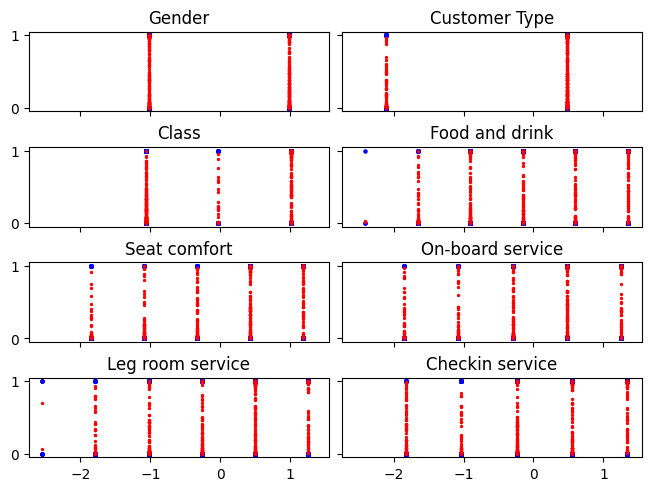

In [28]:
myplot(x_train, y_train, x_test, pred)

In [29]:
df_new = data.sample(5000, random_state=seed_value)
if 'satisfaction' not in columns_to_fill:
    columns_to_fill.append('satisfaction')
df_new = df_new[columns_to_fill]
train_data_new, test_data_new = df_new[:5000 * 8 // 10], df_new[5000 * 8 // 10:]

In [30]:
x_train_new, y_train_new = train_data_new.iloc[:,:-1], train_data_new.iloc[:,-1]
x_test_new, y_test_new = test_data_new.iloc[:,:-1], test_data_new.iloc[:,-1]

In [31]:
history2 = model.fit(x_train_new, y_train_new, epochs=100)

Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 734us/step - accuracy: 0.8452 - loss: 0.3851
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 727us/step - accuracy: 0.8468 - loss: 0.3701
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 719us/step - accuracy: 0.8513 - loss: 0.3523
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 723us/step - accuracy: 0.8541 - loss: 0.3412
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 733us/step - accuracy: 0.8401 - loss: 0.3620
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 730us/step - accuracy: 0.8457 - loss: 0.3528
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 709us/step - accuracy: 0.8554 - loss: 0.3487
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 722us/step - accuracy: 0.8518 - loss: 0.3428
Epoch 9/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 729us/step - accuracy: 0.8425 - loss: 0.3603
Epoch 10/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 717us/step - accuracy: 0.8413 - loss: 0.3535
Epoch 11/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 737us/step - accuracy: 0.8611 - loss: 0.3323
Epoch 12/100
125/12

In [32]:
pred = model.predict(tf.constant(df_new.iloc[1][:-1].values.reshape(-1, 8)))
threshold = 0.5
bipred = (pred > threshold).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [33]:
pred = model.predict(x_test_new)
bipred = (pred > threshold).astype(int)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 783us/step


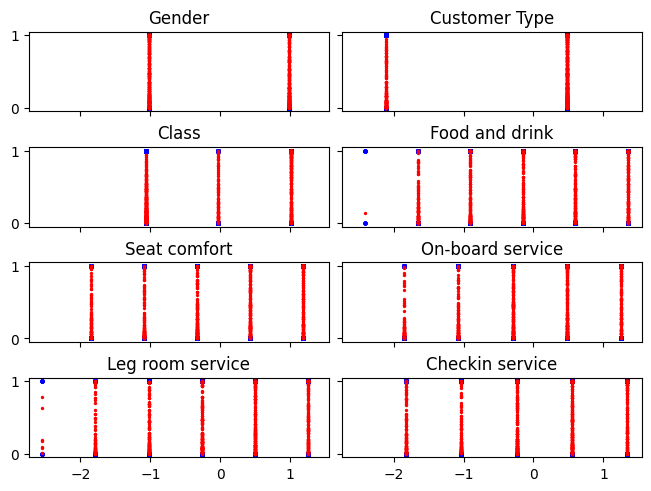

In [34]:
myplot(x_train_new, y_train_new, x_test_new, pred)

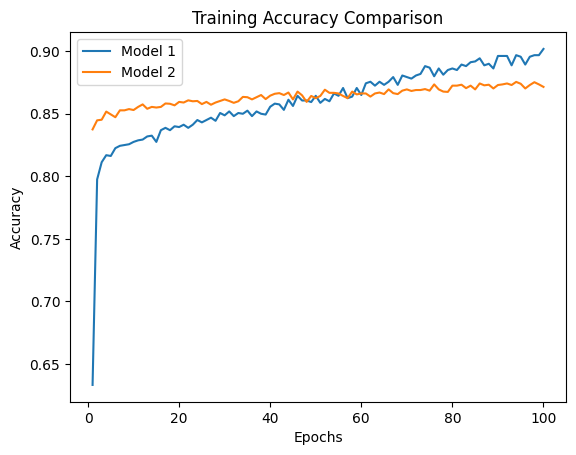

In [35]:
acc1, acc2 = history1.history['accuracy'], history2.history['accuracy']
epochs = range(1, len(acc1) + 1)


plt.plot(epochs, acc1, label='Model 1')
plt.plot(epochs, acc2, label='Model 2')

plt.title('Training Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

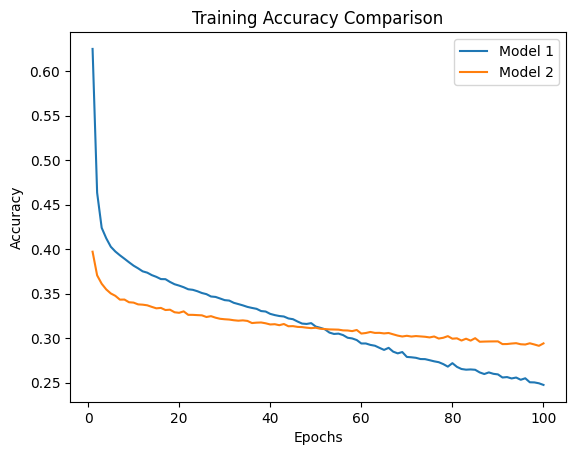

In [36]:
loss1, loss2 = history1.history['loss'], history2.history['loss']

plt.plot(epochs, loss1, label='Model 1')
plt.plot(epochs, loss2, label='Model 2')

plt.title('Training Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()